In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')



: 

### Step 1 : Loading Data

In [ ]:
df = pd.read_csv(os.path.join('../data/raw', "WA_Fn-UseC_-Telco-Customer-Churn.csv"))
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Step 2 : EDA

In [66]:
## Knowning data

data_dict = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.astype(str).values,
    'Unique Values': [df[c].nunique() for c in df.columns],
    'Sample Value': [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns]
})
data_dict

,Column,Dtype,Unique Values,Sample Value
0,customerID,object,7043,7590-VHVEG
1,gender,object,2,Female
2,SeniorCitizen,int64,2,0
3,Partner,object,2,Yes
4,Dependents,object,2,No
5,tenure,int64,73,1
6,PhoneService,object,2,No
7,MultipleLines,object,3,No phone service
8,InternetService,object,3,DSL
9,OnlineSecurity,object,3,No


In [67]:
print(f"Shape : {df.shape}")
print(f"Total missing values : {df.isnull().sum()[df.isnull().sum()> 0]}")
print(f"Total duplicate values : {df.duplicated().sum()}")
print(f"Dtypes :\n{df.dtypes}")

Shape : (7043, 21)
Total missing values : Series([], dtype: int64)
Total duplicate values : 0
Dtypes :
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


Churn Count:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
 Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


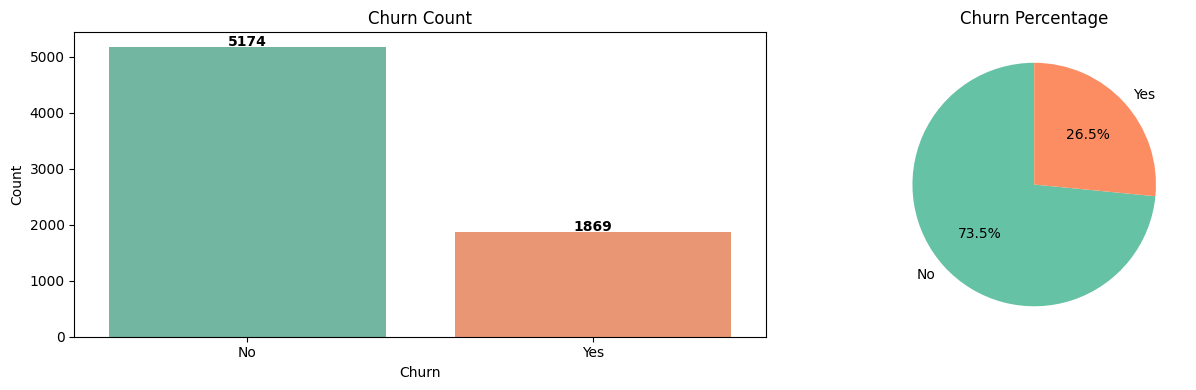

In [68]:
churn_count = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) *100

print("Churn Count:\n", churn_count)
print("\nChurn Percentage:\n", churn_pct)

fig, axes = plt.subplots(1,2, figsize=(14,4))
sns.countplot(data=df, x='Churn', ax=axes[0], palette=['#66c2a5', '#fc8d62'])
for i,v  in enumerate(churn_count):
  axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')
axes[0].set_title("Churn Count")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")

axes[1].pie(churn_pct, labels=churn_pct.index, autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
axes[1].set_title("Churn Percentage")
plt.tight_layout()
plt.show()

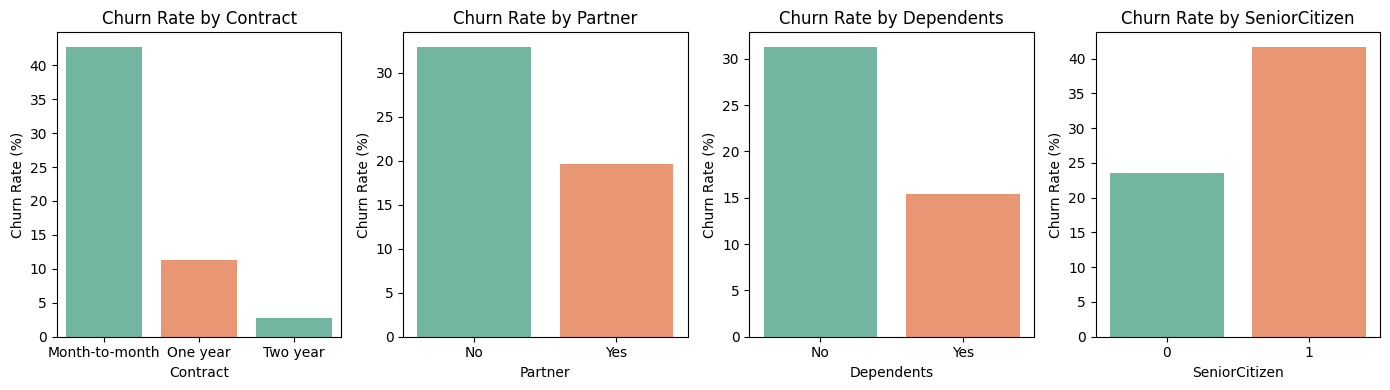

In [69]:
categorical_col = ['Contract','Partner', 'Dependents', 'SeniorCitizen']

fig, axes = plt.subplots(1,4, figsize=(14,4))
for ax, col in zip(axes, categorical_col):
  rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() *100).sort_values(ascending=False)
  sns.barplot(x=rate.index, y=rate.values, ax=ax, palette=['#66c2a5', '#fc8d62'])
  ax.set_title(f"Churn Rate by {col}")
  ax.set_xlabel(col)
  ax.set_ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()


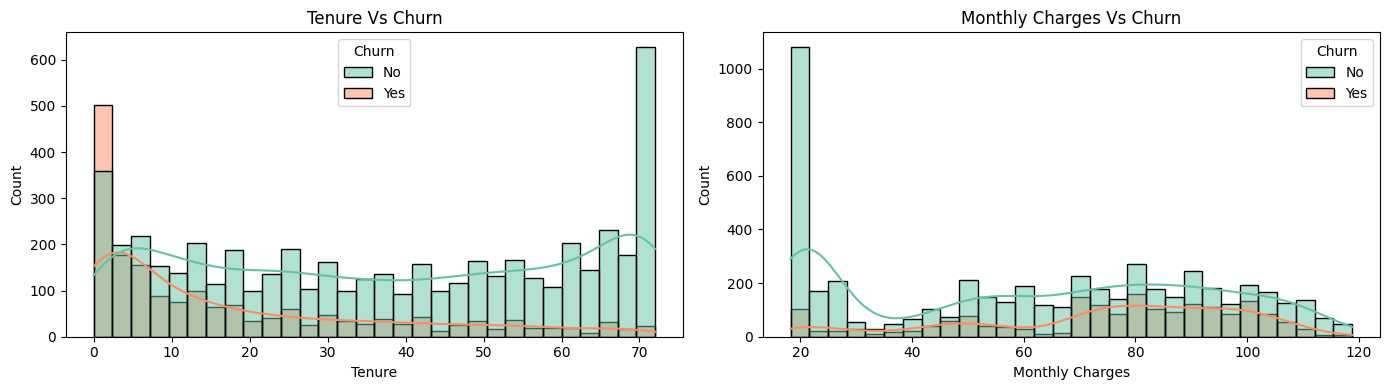

In [70]:
## Tenure Vs churn

fig, axes = plt.subplots(1,2, figsize=(14,4))
sns.histplot(data = df, x='tenure', hue='Churn', bins = 30 , kde=True,  palette=['#66c2a5', '#fc8d62'], ax=axes[0])
axes[0].set_title("Tenure Vs Churn")
axes[0].set_xlabel("Tenure")
axes[0].set_ylabel("Count")

sns.histplot(data = df, x='MonthlyCharges', hue='Churn', bins = 30, kde=True,  palette=['#66c2a5', '#fc8d62'], ax=axes[1])
axes[1].set_title("Monthly Charges Vs Churn")
axes[1].set_xlabel("Monthly Charges")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()



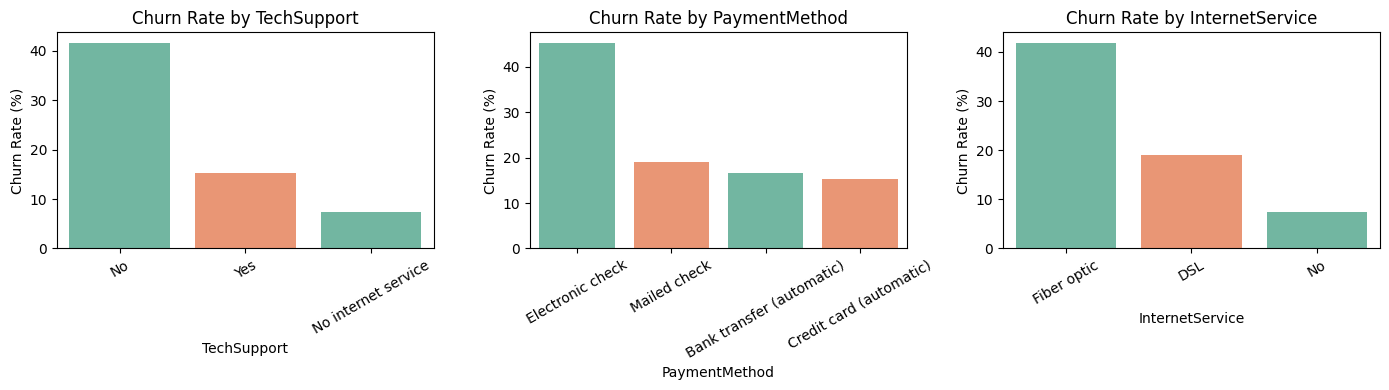

In [71]:
## InternetService Vs churn
categorical_col = ['TechSupport','PaymentMethod','InternetService']
fig, axes = plt.subplots(1,3, figsize=(14,4))
for ax, col in zip(axes, categorical_col):
  rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() *100).sort_values(ascending=False)
  sns.barplot(x=rate.index, y=rate.values, ax=ax, palette=['#66c2a5', '#fc8d62'])
  ax.set_title(f"Churn Rate by {col}")
  ax.set_xlabel(col)
  ax.set_ylabel("Churn Rate (%)")
  ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()



### Step 3: Data Cleaning

In [72]:
## converting dtypes for Total Charges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing TotalCharges after numeric conversion:", df['TotalCharges'].isnull().sum())

## checking Tensure where total charges are null
print(df.loc[df['TotalCharges'].isnull(), 'tenure'].describe())




Missing TotalCharges after numeric conversion: 11
count    11.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: tenure, dtype: float64


In [73]:
## From the above result it seems that for total charge null there is no tenure so we can put the 0 value for those null

df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.drop(columns=['customerID'], inplace=True)
print("Missing TotalCharges after filling nulls:", df['TotalCharges'].isnull().sum())

before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Total duplicate values removed : {before - after}")

print("-- Une")
print(f"Negative tenure : {(df['tenure'] < 0 ).sum()}")
print(f"tenure > 100  : {(df['tenure'] > 100 ).sum()}")

print(f"Negative MonthlyCharges : {(df['MonthlyCharges'] < 0 ).sum()}")
print(f"Negative TotalCharges : {(df['TotalCharges'] < 0 ).sum()}")

numerical_col = ['tenure', 'MonthlyCharges', 'TotalCharges']

print(" -- Checking for outliers -- ")
for col in numerical_col:
  Q1, Q3 = df[col].quantile([0.25, 0.75])
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outlier = ((df[col] > upper_bound ) | (df[col] < lower_bound)).sum()
  df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
  df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
  print(f"{col} :  {outlier} outliers")


Missing TotalCharges after filling nulls: 0
Total duplicate values removed : 22
-- Une
Negative tenure : 0
tenure > 100  : 0
Negative MonthlyCharges : 0
Negative TotalCharges : 0
 -- Checking for outliers -- 
tenure :  0 outliers
MonthlyCharges :  0 outliers
TotalCharges :  0 outliers


InternetServicesCount
1    45.755694
2    35.818006
3    27.370304
4    22.300469
0    21.074192
5    12.434326
6     5.281690
Name: Churn, dtype: float64


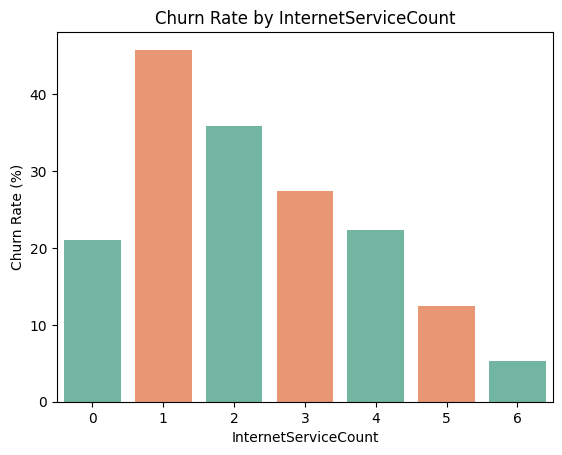

In [74]:
## Will do some feature engineering

df['InternetServicesCount'] = (
    (df['OnlineSecurity'] == 'Yes').astype(int) +
    (df['OnlineBackup'] == 'Yes').astype(int) +
    (df['DeviceProtection'] == 'Yes').astype(int) +
    (df['TechSupport'] == 'Yes').astype(int) +
    (df['StreamingTV'] == 'Yes').astype(int) +
    (df['StreamingMovies'] == 'Yes').astype(int)
)
rate = df.groupby('InternetServicesCount')['Churn'].mean().mul(100).sort_values(ascending=False)
print(rate)
sns.barplot(x=rate.index, y=rate.values, palette=['#66c2a5', '#fc8d62'])
plt.title("Churn Rate by InternetServiceCount")
plt.xlabel("InternetServiceCount")
plt.ylabel("Churn Rate (%)")
plt.show()



### Step 4 : Train/Test Split



In [75]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y ,random_state=42)
print(f"Training size :  {X_train.shape[0]}")
print(f"Testing size : {X_test.shape[0]}")

Training size :  5616
Testing size : 1405


### Step 5 : Preprocessing
1. Scaling for numerical data
2. Onehot encoding for categorical data

In [77]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'InternetServicesCount'
]

categorical_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numerical_cols),
        ('cat',OneHotEncoder(drop='first',handle_unknown='ignore', sparse_output=False),categorical_cols)
    ]
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print("Preprocessed Training Data Shape:", X_train_preprocessed.shape)
print("Preprocessed Testing Data Shape:", X_test_preprocessed.shape)


Preprocessed Training Data Shape: (5616, 31)
Preprocessed Testing Data Shape: (1405, 31)


### Step 6 : Baseline Model

Accuracy: 0.8021352313167259
Precision: 0.6598639455782312
Recall: 0.521505376344086
F1 Score: 0.5825825825825826

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.52      0.58       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.73      1405
weighted avg       0.79      0.80      0.79      1405


Confusion Matrix:
 [[933 100]
 [178 194]]


<Axes: >

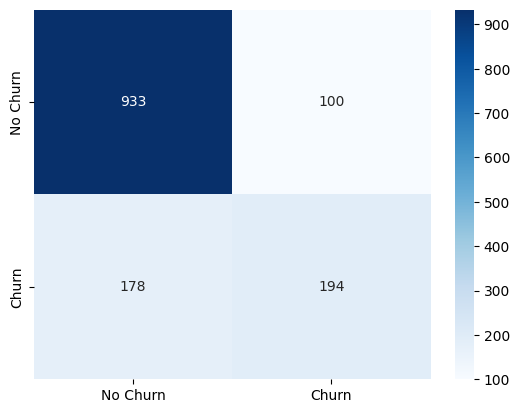

In [83]:

## Base line model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
model = LogisticRegression(max_iter = 1000)
model.fit(X_train_preprocessed, y_train)

y_pred = model.predict(X_test_preprocessed)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])

In [82]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

## Checkign for multiple models
random_state = 42

models = {
    'Logistic Regression': LogisticRegression(max_iter = 2000,random_state=random_state),
    'Decision Tree': DecisionTreeClassifier(random_state=random_state,class_weight='balanced',max_depth = 8),
    'Random Forest': RandomForestClassifier(random_state=random_state,class_weight='balanced',max_depth = 8),
    'Gradient Boosting': GradientBoostingClassifier(random_state=random_state),
    'XGBoost': XGBClassifier(random_state=random_state)
}

results =[]

for model_name, model in models.items():
    model.fit(X_train_preprocessed, y_train)
    y_pred = model.predict(X_test_preprocessed)
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_pred)})


results_df = pd.DataFrame(results)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.802135   0.659864  0.521505  0.582583  0.712350
1        Decision Tree  0.738790   0.504521  0.750000  0.603243  0.742377
2        Random Forest  0.767260   0.543186  0.760753  0.633819  0.765178
3    Gradient Boosting  0.801423   0.666667  0.500000  0.571429  0.704985
4              XGBoost  0.780071   0.608997  0.473118  0.532526  0.681864


1. Data Ingestion:
    Loading the data
    renaming columns
    saving the data

2. Data preprocessing:
    loading data
    EDA
    checking missing values
    removing outliers
    removing duplicates
    spliting data
    saving data

3. Feature Enginering:
    loading data
    feature scaling
    encoding
    feature selection

4. Model building
    

